In [1]:
import pandas as pd
import numpy as np

# Interpolation vs Extrapolation

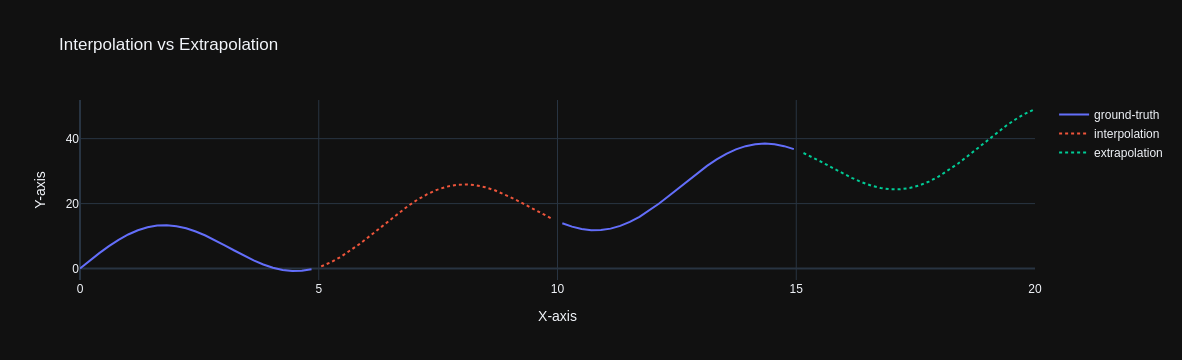

In [6]:
import numpy as np
import pandas as pd
import plotly.express as px

# Sample data
x = np.linspace(0, 20, 100)
y = 10 * np.sin(x / 1) + 2 * x

# Create a DataFrame
df = pd.DataFrame({
    'x': x,
    'ground-truth': y
})

# Mask for interpolation and extrapolation
mask_interpolation = (x > 5) & (x < 10)
df.loc[mask_interpolation, 'interpolation'] = df['ground-truth']
df.loc[mask_interpolation, 'ground-truth'] = np.nan

mask_extrapolation = (x > 15)
df.loc[mask_extrapolation, 'extrapolation'] = df['ground-truth']
df.loc[mask_extrapolation, 'ground-truth'] = np.nan

# Create a line plot
fig = px.line(df, x='x', y=['ground-truth', 'interpolation', 'extrapolation'], 
              title='Interpolation vs Extrapolation', 
              labels={'x': 'X-axis', 'value': 'Y-axis', 'variable': ""})

# Update traces to set opacity for interpolation and extrapolation
fig.update_traces(opacity=1.0, selector=dict(name='y'))  # Original line (no transparency)
fig.update_traces(opacity=1.0, line_dash='dot', selector=dict(name='interpolation'))  # Semi-transparent interpolation
fig.update_traces(opacity=1.0, line_dash='dot', selector=dict(name='extrapolation'))  # Semi-transparent extrapolation

# Set the layout template to dark
fig.layout.template = "plotly_dark"

# Show the plot
fig.show()

In [7]:
fig.write_html("interpolation_extrapolation.html", include_plotlyjs='cdn')